<a href="https://colab.research.google.com/github/Deangr-econ/Quant_methods_project/blob/main/VAR_GPRD_OIL_GAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from fredapi import Fred
from google.colab import userdata

In [28]:
# 1. Load GPR data
gpr = pd.read_stata("/content/drive/Othercomputers/My Laptop/Documents/Maastricht University/Master/Quantitative Techniques for Financial Economics/data_gpr_daily_recent.dta")
gpr['date'] = pd.to_datetime(gpr['date'])
gpr = gpr.set_index('date')

fred = Fred(api_key=userdata.get('fredapi_key'))
oil_data = fred.get_series('DCOILBRENTEU', observation_start='1985-01-01')
gas_data = fred.get_series('DHHNGSP', observation_start='1985-01-01')
crude_volatility = fred.get_series('OVXCLS', observation_start='1985-01-01')
ten_y_exp_inflation = fred.get_series('T10YIE', observation_start='1985-01-01')

fred_data = pd.DataFrame({
    'OIL_PRICE': oil_data,
    'GAS_PRICE': gas_data,
    'CRUDE_VOLATILITY': crude_volatility,
    'EXP_INFLATION': ten_y_exp_inflation
    })

In [31]:
# # 2. Download Energy Futures
# fred_data = yf.download(
#     tickers=['CL=F', 'NG=F'],
#     start='1990-01-01',
#     auto_adjust=True
# )['Close']

# Strip timezone if present
fred_data.index = pd.to_datetime(fred_data.index).tz_localize(None)
gpr.index = pd.to_datetime(gpr.index).tz_localize(None)

merged = fred_data.join(gpr['GPRD'], how='inner')
# 2. Find the first timestamp where ALL columns have non-null values
first_valid = merged.dropna().index.min()
# 3. Slice from that date onward
data = merged.loc[first_valid:].dropna()

# 4. Clean non-positive crude anomaly (2020-04-20)
data['OIL_PRICE'] = data['OIL_PRICE'].mask(data['OIL_PRICE'] <= 0).ffill()

# 5. Build explicit stationary DataFrame for VAR estimation
var_df = pd.DataFrame(index=data.index)
var_df['OIL'] = np.log(data['OIL_PRICE']).diff()
var_df['GAS'] = np.log(data['GAS_PRICE']).diff()
var_df['CRUDE_VOLATILITY'] = np.log(data['CRUDE_VOLATILITY']).diff()
var_df['EXP_INFLATION'] = np.log(data['EXP_INFLATION']).diff()

# Use log-difference for GPR (clipped to avoid log(0))
var_df['GPRD'] = np.log(data['GPRD'].clip(lower=1e-5)).diff()

# Drop initial NaN created by differencing
var_df = var_df.dropna()

In [72]:
#  Clip extreme outliers in EXP_INFLATION to +/- 4 standard deviations
# There were extreme 47 std outliers in the expected inflation data

lower_bound = var_df['EXP_INFLATION'].quantile(0.001)
upper_bound = var_df['EXP_INFLATION'].quantile(0.999)

var_df_clean = var_df.copy()
var_df_clean['EXP_INFLATION'] = var_df_clean['EXP_INFLATION'].clip(lower=lower_bound, upper=upper_bound)

# Refit standard model
model = VAR(var_df_clean)

# model = VAR(endog=var_df)
# Evaluate lags 1 through 15
lag_order = model.select_order(maxlags=40)
print(lag_order.summary())

# Choose lag by AIC (more flexible) or BIC (more parsimonious)
optimal_lag = lag_order.hqic
print(f"Optimal lag according to AIC: {optimal_lag}")

# Fit the VAR model with the selected lag
results = model.fit(optimal_lag)
total_coefs = results.params.size
print(f"Total regression coefficients: {total_coefs}")

print(results.summary())



# # Does GPR predict Oil returns?
# gc_oil = results.test_causality('OIL', ['GPRD'], kind='f')
# print("Granger Causality (GPR -> Oil):")
# print(gc_oil.summary())

# # Does GPR predict Gas returns?
# gc_gas = results.test_causality('GAS', ['GPRD'], kind='f')
# print("\nGranger Causality (GPR -> Gas):")
# print(gc_gas.summary())




/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -26.92      -26.91   2.044e-12      -26.91
1       -27.19      -27.15   1.549e-12      -27.18
2       -27.33      -27.25   1.354e-12      -27.30
3       -27.38     -27.27*   1.290e-12      -27.34
4       -27.41      -27.26   1.249e-12      -27.36
5       -27.42      -27.24   1.233e-12      -27.36
6       -27.43      -27.22   1.223e-12      -27.36
7       -27.45      -27.20   1.200e-12      -27.36
8       -27.48      -27.19   1.169e-12     -27.38*
9       -27.48      -27.16   1.167e-12      -27.37
10      -27.48      -27.13   1.164e-12      -27.36
11      -27.48      -27.10   1.165e-12      -27.34
12      -27.48      -27.07   1.160e-12      -27.34
13      -27.49      -27.04   1.153e-12      -27.33
14      -27.50      -27.02   1.138e-12      -27.33
15      -27.51      -26.99   1.134e-12      -27.32
16      -27.51      -26.96   1.

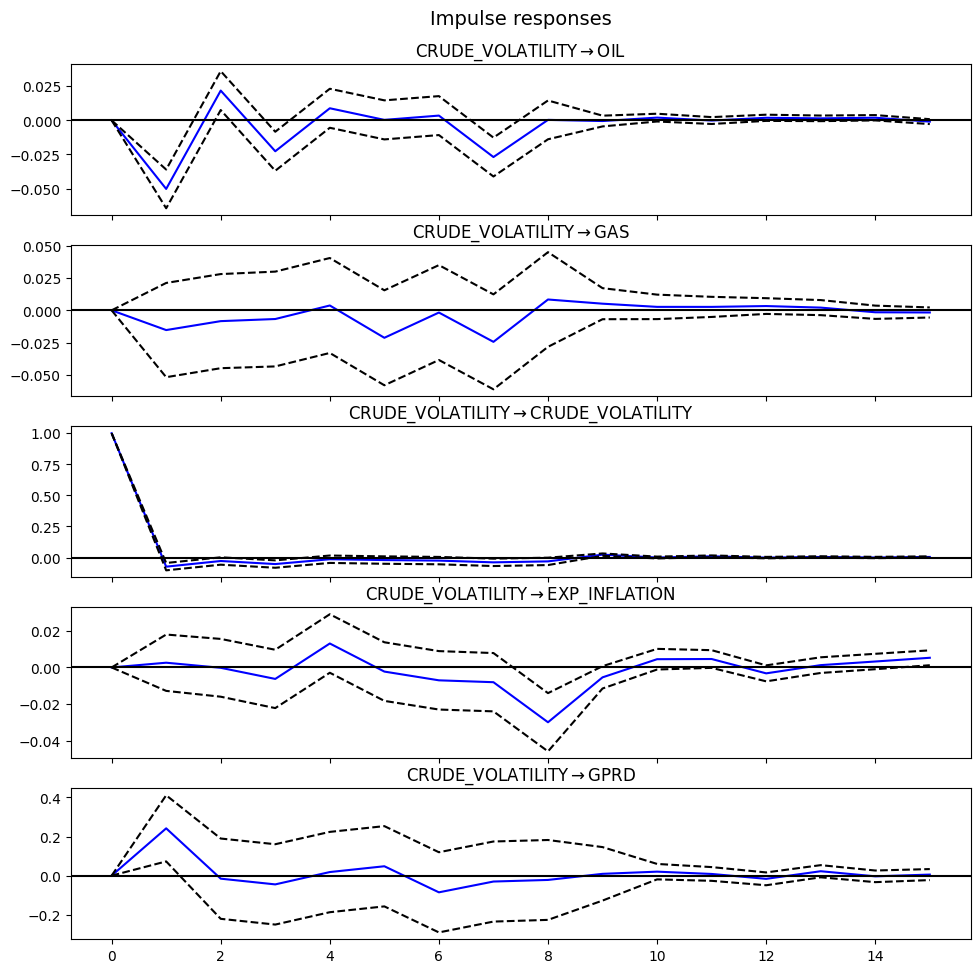

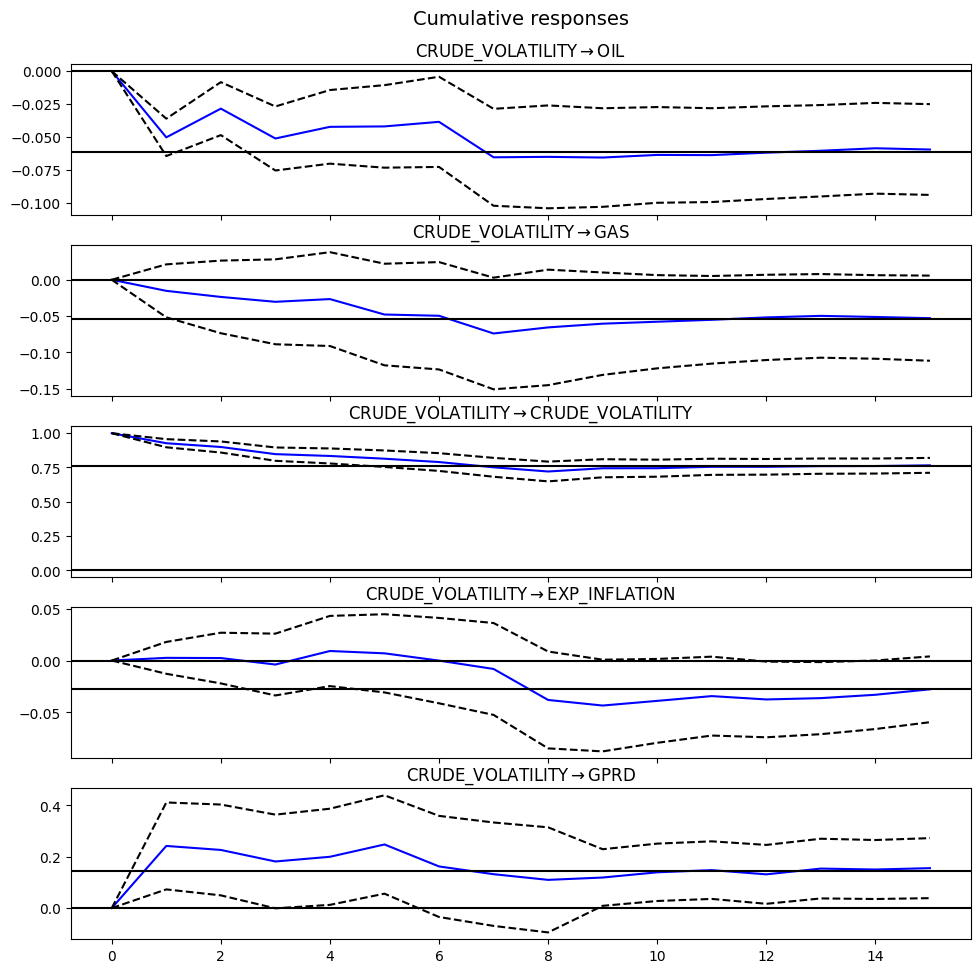

In [73]:
# Compute orthogonalized IRFs (default uses Cholesky ordering based on DataFrame column order)
irf = results.irf(periods=15)

# Plot responses to a GPR shock
fig = irf.plot(impulse='CRUDE_VOLATILITY')
plt.show()

# Cumulative IRF (to see net directional impact over time)
fig_cum = irf.plot_cum_effects(impulse='CRUDE_VOLATILITY')
plt.show()

In [60]:
fevd = results.fevd(10)
print(fevd.summary())
# fevd.plot()
# plt.show()

FEVD for OIL
          OIL       GAS  CRUDE_VOLATILITY  EXP_INFLATION      GPRD
0    1.000000  0.000000          0.000000       0.000000  0.000000
1    0.988574  0.000326          0.010251       0.000789  0.000060
2    0.984879  0.000651          0.012514       0.001882  0.000075
3    0.982864  0.000805          0.014079       0.001880  0.000372
4    0.978554  0.000923          0.014684       0.005437  0.000402
5    0.978303  0.000990          0.014724       0.005582  0.000402
6    0.977625  0.001083          0.014836       0.006054  0.000402
7    0.974213  0.001079          0.017289       0.006994  0.000425
8    0.974179  0.001078          0.017292       0.006988  0.000463
9    0.974079  0.001079          0.017291       0.006999  0.000552

FEVD for GAS
          OIL       GAS  CRUDE_VOLATILITY  EXP_INFLATION      GPRD
0    0.002155  0.997845          0.000000       0.000000  0.000000
1    0.002289  0.997542          0.000161       0.000002  0.000006
2    0.002264  0.997471          0.

In [52]:
def plot_var_residual_diagnostics(var_results, equation_name, lags=20, bins=70):
    """
    Plots a 4-panel residual diagnostic grid for a single equation in a fitted VAR model.
    """
    # 1. Extract 1D residual series for the target equation
    resid = var_results.resid[equation_name].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # --- Panel 1: Residuals Over Time ---
    axes[0, 0].plot(resid.index, resid.values, color="#1f77b4", lw=0.8, alpha=0.85)
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.9)
    axes[0, 0].set_title(f"Residuals Over Time: {equation_name} (Volatility Clustering)", fontweight="bold")
    axes[0, 0].set_ylabel("Residual")
    axes[0, 0].grid(True, alpha=0.3)

    # --- Panel 2: Density vs Theoretical Normal ---
    axes[0, 1].hist(resid, bins=bins, density=True, alpha=0.55, color="#2ca02c", edgecolor="none")
    mu, std = stats.norm.fit(resid)
    xmin, xmax = axes[0, 1].get_xlim()
    x_pdf = np.linspace(xmin, xmax, 500)
    kurt = stats.kurtosis(resid, fisher=False)  # Pearson kurtosis (normal = 3.0)
    skew = stats.skew(resid)

    axes[0, 1].plot(
        x_pdf, stats.norm.pdf(x_pdf, mu, std), "r--", lw=2,
        label=rf"Normal ($\mu={mu:.3f}, \sigma={std:.3f}$)"
    )
    axes[0, 1].set_title(f"Empirical vs. Normal (Kurtosis: {kurt:.1f}, Skew: {skew:.2f})", fontweight="bold")
    axes[0, 1].set_ylabel("Density")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # --- Panel 3: Q-Q Plot (Heavy Tails) ---
    sm.qqplot(resid, line="45", fit=True, ax=axes[1, 0], color="#1f77b4", alpha=0.5)
    axes[1, 0].set_title("Normal Q-Q Plot (Tail Extremity)", fontweight="bold")
    axes[1, 0].grid(True, alpha=0.3)

    # --- Panel 4: Autocorrelation Function (ACF) ---
    sm.graphics.tsa.plot_acf(resid, lags=lags, ax=axes[1, 1], alpha=0.05)
    axes[1, 1].set_title(f"Residual ACF (Up to {lags} Lags)", fontweight="bold")
    axes[1, 1].set_xlabel("Lag")
    axes[1, 1].set_ylabel("Autocorrelation")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Example Usage:
# plot_var_residual_diagnostics(results, 'OIL')
# plot_var_residual_diagnostics(results, 'GAS')

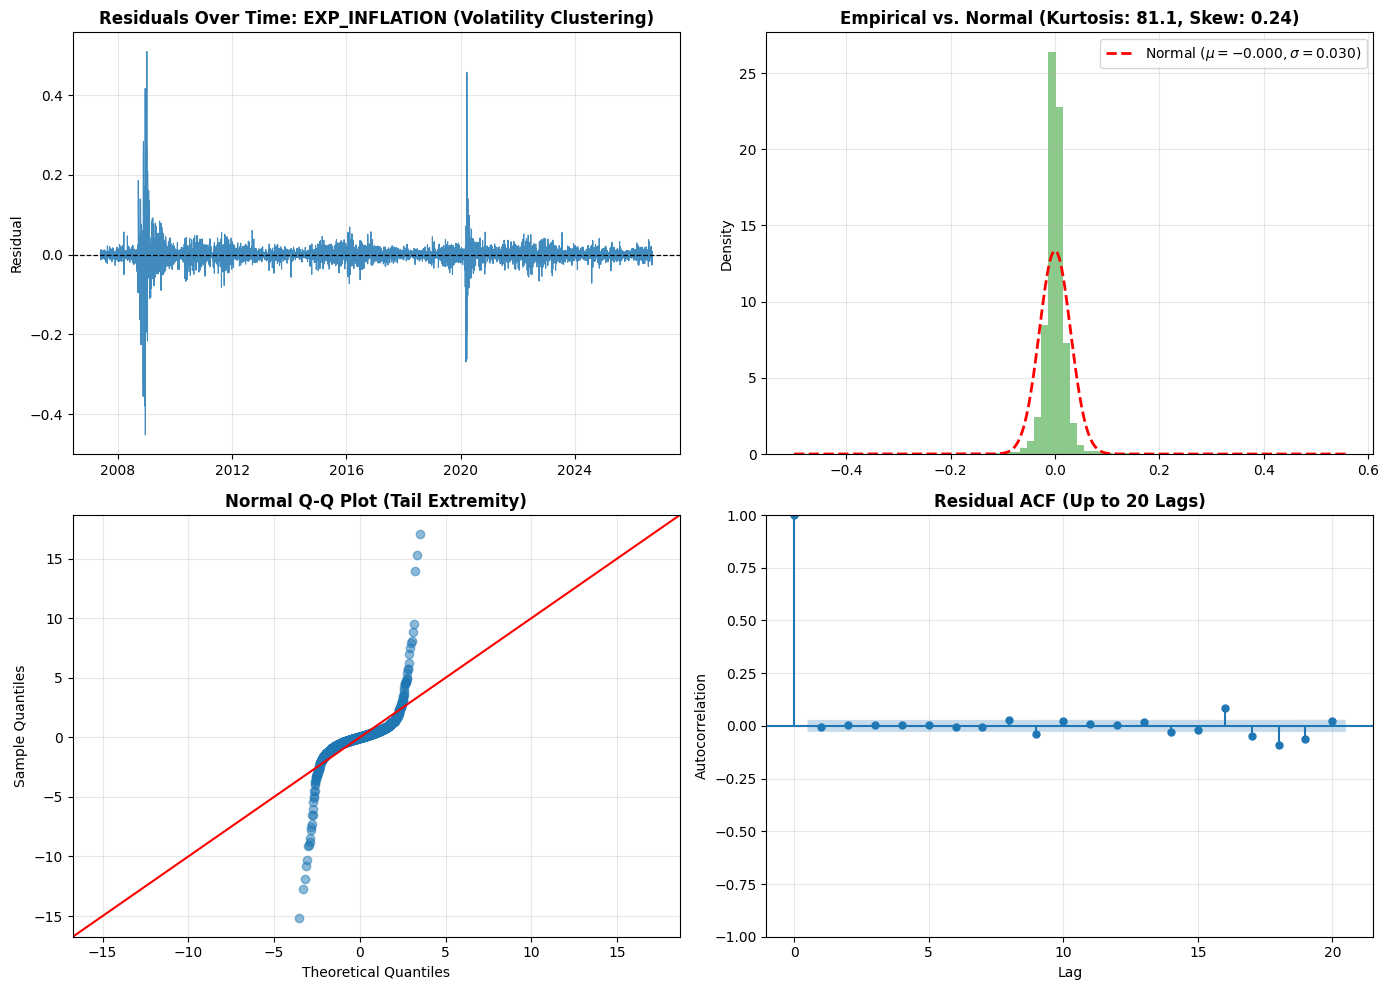

In [74]:
plot_var_residual_diagnostics(results, 'EXP_INFLATION')

In [67]:
# Find the exact date of the worst drop
worst_date = var_df['EXP_INFLATION'].idxmin()
print("Worst outlier date:", worst_date)
print("Outlier value:", var_df.loc[worst_date, 'EXP_INFLATION'])

# Check the top 5 most extreme absolute swings
print("\nTop 5 absolute swings in EXP_INFLATION:")
print(var_df['EXP_INFLATION'].abs().nlargest(5))

Worst outlier date: 2008-11-20 00:00:00
Outlier value: -2.3025850929940455

Top 5 absolute swings in EXP_INFLATION:
2008-11-20   2.3026
2008-11-24   1.5686
2009-01-06   1.0296
2008-12-17   0.7538
2008-12-12   0.5341
Name: EXP_INFLATION, dtype: float64
